# Used Cars Analysis: Decoding the UK Used Car Market
---

### Opening Question
**What factors influence the road tax and fuel efficiency of used cars? How do brand, age, mileage, engine size, and fuel type affect tax and MPG? Is there a sweet spot that balances low tax with high fuel economy?**

### Objective
To uncover patterns in the UK used car market by analysing the relationships between car characteristics (brand, model, year, transmission, mileage, fuel type, engine size) and key metrics like annual road tax and fuel efficiency (MPG). Rather than making assumptions, I'll examine actual correlations and distributions to identify what drives tax costs and economy.

### Dataset Overview
- **Sample Size**: 3,000+ used car listings
- **Variables**: carID, brand, model, year, transmission, mileage, fuelType, tax (annual road tax in GBP), mpg (miles per gallon), engineSize (litres)
- **Analysis Approach**: Exploratory Data Analysis [EDA], focusing on distributions, brand comparisons, and relationships between numeric variables through visualisations and statistical summaries, followed by a predictive model for tax.

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# set visualisation style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

In [70]:
# colour scheme for consistency
primary = "#d59de3"
secondary = "#345882"
success = "#2ca02c"
danger = "#d62728"
warning = "#ff9896"

# gradient for distributions
gradient = ["#d59de3", "#c598dd", "#b592d7", "#a48cd1", "#9386ca", "#8180c2", "#6f7bbb", "#5f74b1", "#526da6", "#46679b", "#3d5f8e", "#345882"]

### 1. What does the dataset look like at first glance?

Let's load the data, inspect structure, size, and get an initial sense of what we're working with.

In [71]:
# load the dataset
df = pd.read_csv("usedcars.csv")

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names and types:\n{df.dtypes}")

Dataset shape: (2672, 10)

Column names and types:
carID             int64
brand               str
model               str
year              int64
transmission        str
mileage           int64
fuelType            str
tax             float64
mpg             float64
engineSize      float64
dtype: object


In [72]:
# first few rows
print("Sample listings:")
df.head()

Sample listings:


,carID,brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,12000,merc,GLS Class,2017,Automatic,12046,Diesel,150.0,37.2,3.0
1,12001,vw,Amarok,2017,Automatic,37683,Diesel,260.0,36.2,3.0
2,12004,merc,GLS Class,2019,Automatic,10000,Diesel,145.0,34.0,3.0
3,12013,skoda,Scala,2019,Manual,3257,Petrol,145.0,49.6,1.0
4,12017,audi,RS6,2015,Semi-Auto,20982,Petrol,325.0,29.4,4.0


In [73]:
# basic statistics
print("\nNumeric summary:")
df.describe()


Numeric summary:


,carID,year,mileage,tax,mpg,engineSize
count,2672.000000,2672.000000,2672.000000,2672.000000,2672.000000,2672.000000
mean,15784.043039,2016.720434,24617.528443,153.261602,49.787275,2.135105
std,2197.045979,2.898906,23142.032992,80.742530,35.269981,0.768596
min,12000.000000,1970.000000,1.000000,0.000000,2.800000,0.000000
25%,13889.750000,2016.000000,6000.000000,145.000000,37.700000,1.600000
50%,15777.500000,2017.000000,18548.000000,145.000000,47.100000,2.000000
75%,17661.500000,2019.000000,36272.250000,160.000000,54.300000,2.800000
max,19631.000000,2020.000000,167054.000000,580.000000,470.800000,6.300000


In [74]:
# data quality check
print("\nMissing values:")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({"Missing": missing_data, "Percent": missing_percent})
print(missing_df[missing_df["Missing"] > 0])

print(f"\nDuplicate rows: {df.duplicated().sum()}")


Missing values:
Empty DataFrame
Columns: [Missing, Percent]
Index: []

Duplicate rows: 0


### 2. Understanding Brand, Transmission, and Fuel Type Distribution

Which brands dominate the used car market? What transmissions and fuels are most common?

Brand distribution:
brand
ford        430
merc        429
vw          391
bmw         340
hyundi      306
toyota      271
skoda       213
audi        180
vauxhall    112
Name: count, dtype: int64

Percentages (top 15):
brand
ford        16.09
merc        16.06
vw          14.63
bmw         12.72
hyundi      11.45
toyota      10.14
skoda        7.97
audi         6.74
vauxhall     4.19
Name: count, dtype: float64


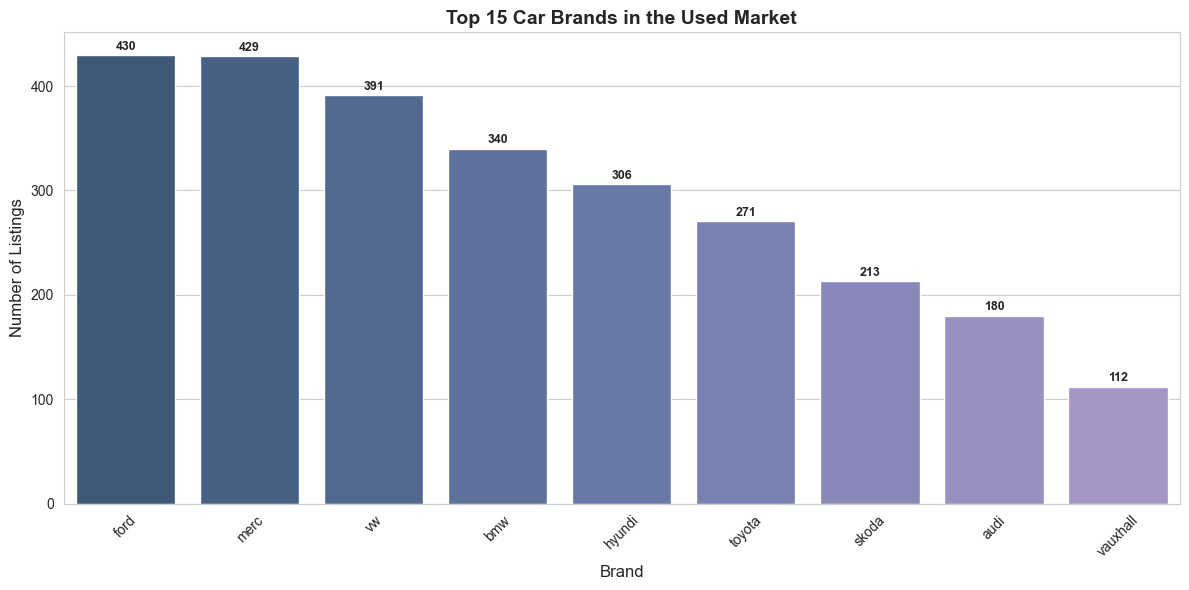

In [75]:
# brand distribution
brand_counts = df["brand"].value_counts()
print("Brand distribution:")
print(brand_counts.head(15))
print(f"\nPercentages (top 15):")
print((brand_counts.head(15) / len(df) * 100).round(2))

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=brand_counts.head(15).index, y=brand_counts.head(15).values, palette=gradient[::-1], ax=ax)
ax.set_title('Top 15 Car Brands in the Used Market', fontsize=14, fontweight='bold')
ax.set_xlabel('Brand', fontsize=12)
ax.set_ylabel('Number of Listings', fontsize=12)
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(brand_counts.head(15).values):
    ax.text(i, v + 5, f'{v}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()


Transmission distribution:
transmission
Manual       989
Automatic    928
Semi-Auto    754
Other          1
Name: count, dtype: int64

Percentages:
transmission
Manual       37.01
Automatic    34.73
Semi-Auto    28.22
Other         0.04
Name: count, dtype: float64


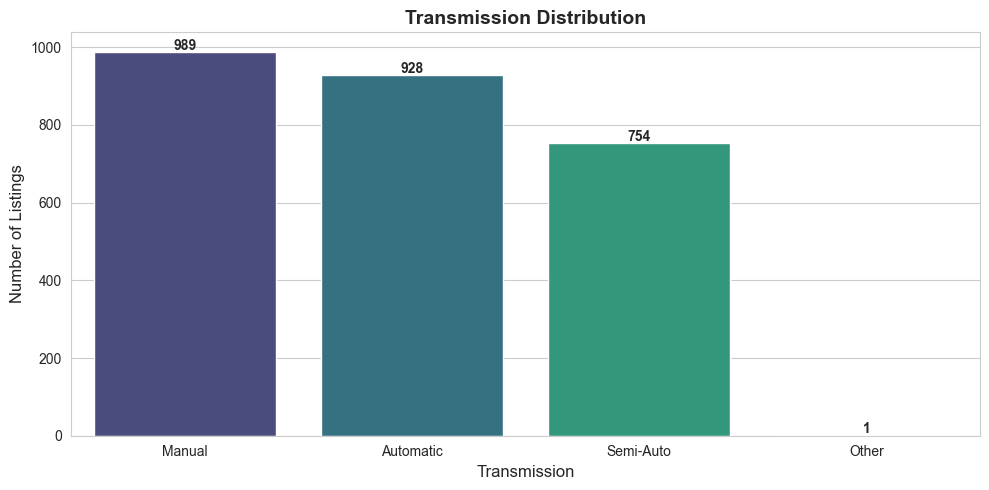

In [76]:
# transmission distribution
print("\nTransmission distribution:")
trans_counts = df["transmission"].value_counts()
print(trans_counts)
print(f"\nPercentages:")
print((trans_counts / len(df) * 100).round(2))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=trans_counts.index, y=trans_counts.values, palette='viridis', ax=ax)
ax.set_title('Transmission Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Transmission', fontsize=12)
ax.set_ylabel('Number of Listings', fontsize=12)
for i, v in enumerate(trans_counts.values):
    ax.text(i, v + 5, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


Fuel type distribution:
fuelType
Diesel      1662
Petrol       901
Hybrid        98
Other         10
Electric       1
Name: count, dtype: int64

Percentages:
fuelType
Diesel      62.20
Petrol      33.72
Hybrid       3.67
Other        0.37
Electric     0.04
Name: count, dtype: float64


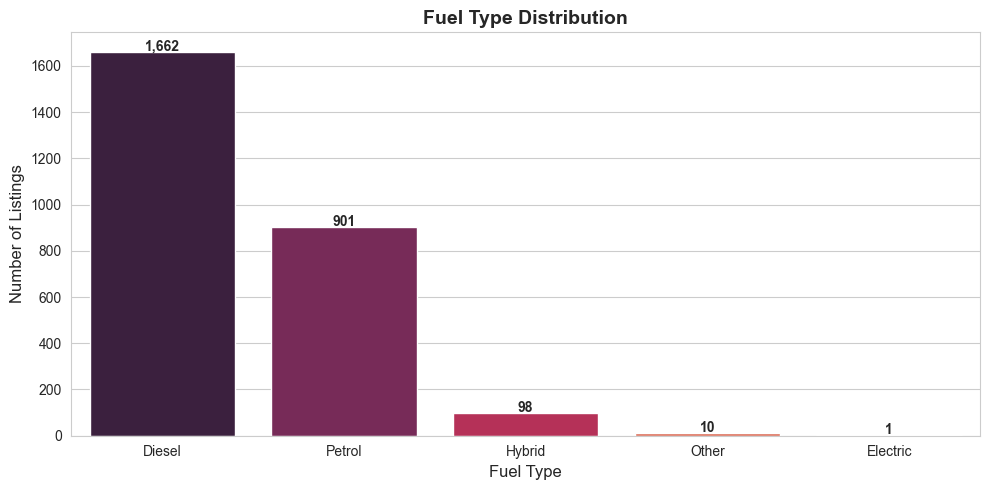

In [77]:
# fuel type distribution
print("\nFuel type distribution:")
fuel_counts = df["fuelType"].value_counts()
print(fuel_counts)
print(f"\nPercentages:")
print((fuel_counts / len(df) * 100).round(2))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=fuel_counts.index, y=fuel_counts.values, palette='rocket', ax=ax)
ax.set_title('Fuel Type Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Fuel Type', fontsize=12)
ax.set_ylabel('Number of Listings', fontsize=12)
for i, v in enumerate(fuel_counts.values):
    ax.text(i, v + 5, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

### 3. Age, Mileage, and Engine Size Distributions

What's the typical age, mileage, and engine size of used cars on offer?

Car age statistics (years):
Mean: 9.3
Median: 9.0
Min: 6
Max: 56


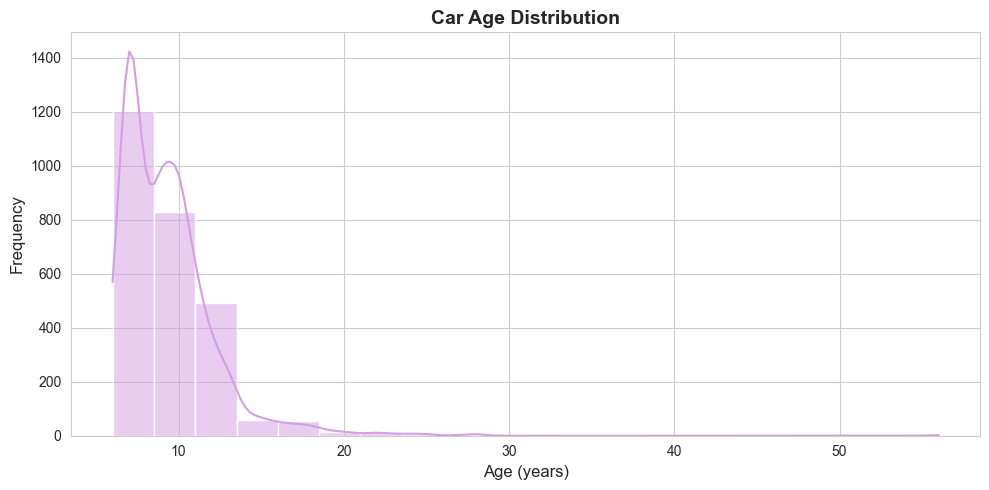

In [78]:
# year distribution (convert to age)
current_year = 2026  # approximate
df['age'] = current_year - df['year']
print("Car age statistics (years):")
print(f"Mean: {df['age'].mean():.1f}")
print(f"Median: {df['age'].median():.1f}")
print(f"Min: {df['age'].min():.0f}")
print(f"Max: {df['age'].max():.0f}")

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['age'], bins=20, kde=True, color=primary, ax=ax)
ax.set_title('Car Age Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

Mileage statistics (miles):
Mean: 24,618
Median: 18,548
Min: 1
Max: 167,054


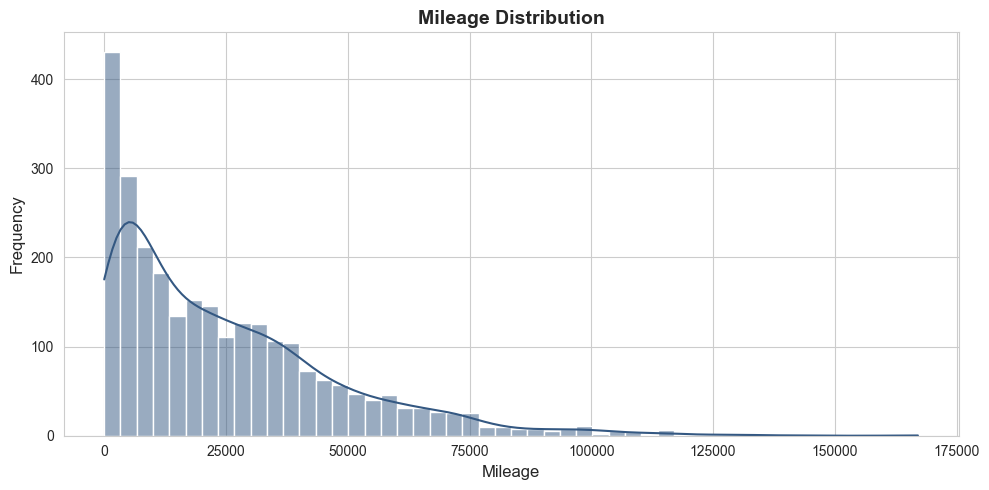

In [79]:
# mileage statistics
print("Mileage statistics (miles):")
print(f"Mean: {df['mileage'].mean():,.0f}")
print(f"Median: {df['mileage'].median():,.0f}")
print(f"Min: {df['mileage'].min():,.0f}")
print(f"Max: {df['mileage'].max():,.0f}")

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['mileage'], bins=50, kde=True, color=secondary, ax=ax)
ax.set_title('Mileage Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Mileage', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

Engine size statistics (litres):
Mean: 2.14
Median: 2.00
Min: 0.0
Max: 6.3


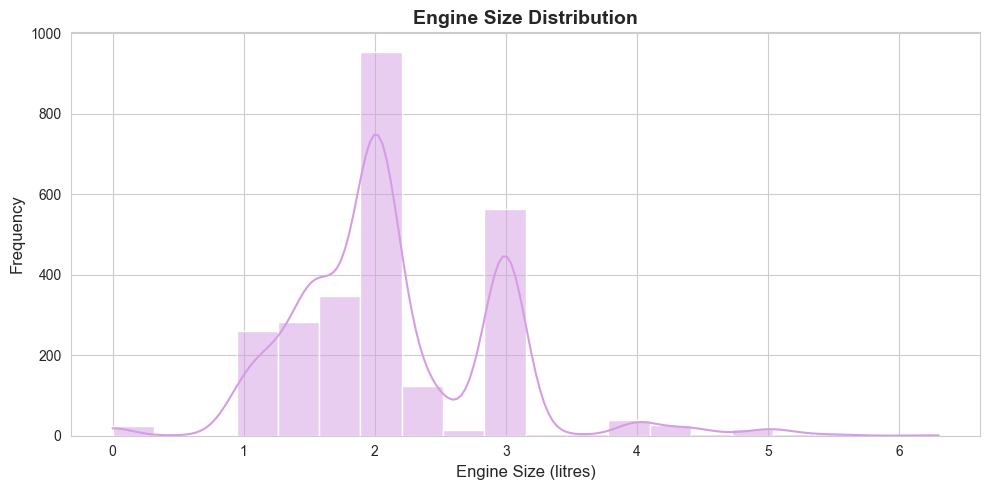

In [80]:
# engine size statistics
print("Engine size statistics (litres):")
print(f"Mean: {df['engineSize'].mean():.2f}")
print(f"Median: {df['engineSize'].median():.2f}")
print(f"Min: {df['engineSize'].min():.1f}")
print(f"Max: {df['engineSize'].max():.1f}")

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['engineSize'], bins=20, kde=True, color=primary, ax=ax)
ax.set_title('Engine Size Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Engine Size (litres)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

### 4. Tax and MPG Analysis

What are the typical annual road tax costs and fuel efficiency? How do they vary?

Annual road tax (GBP):
Mean: £153.26
Median: £145.00
Min: £0.00
Max: £580.00


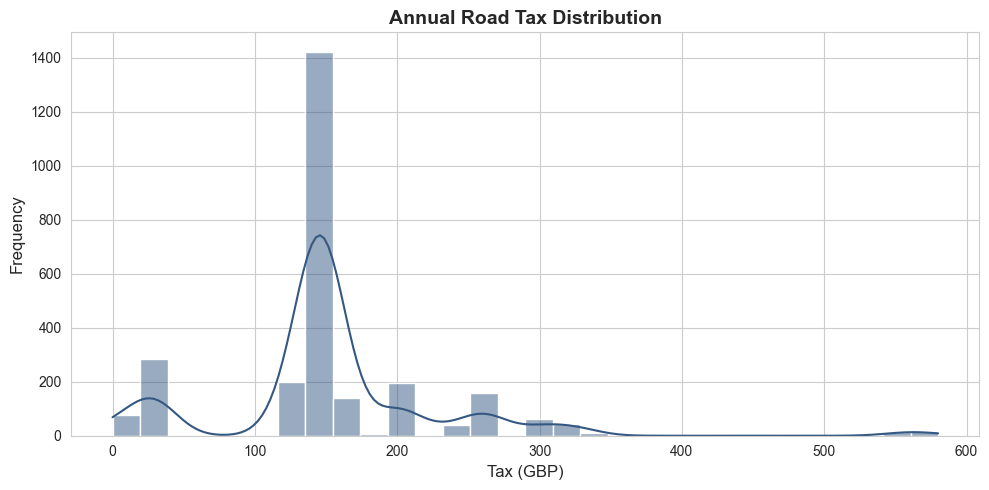

In [81]:
# tax statistics
print("Annual road tax (GBP):")
print(f"Mean: £{df['tax'].mean():.2f}")
print(f"Median: £{df['tax'].median():.2f}")
print(f"Min: £{df['tax'].min():.2f}")
print(f"Max: £{df['tax'].max():.2f}")

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['tax'], bins=30, kde=True, color=secondary, ax=ax)
ax.set_title('Annual Road Tax Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Tax (GBP)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

MPG statistics:
Mean: 49.8
Median: 47.1
Min: 2.8
Max: 470.8


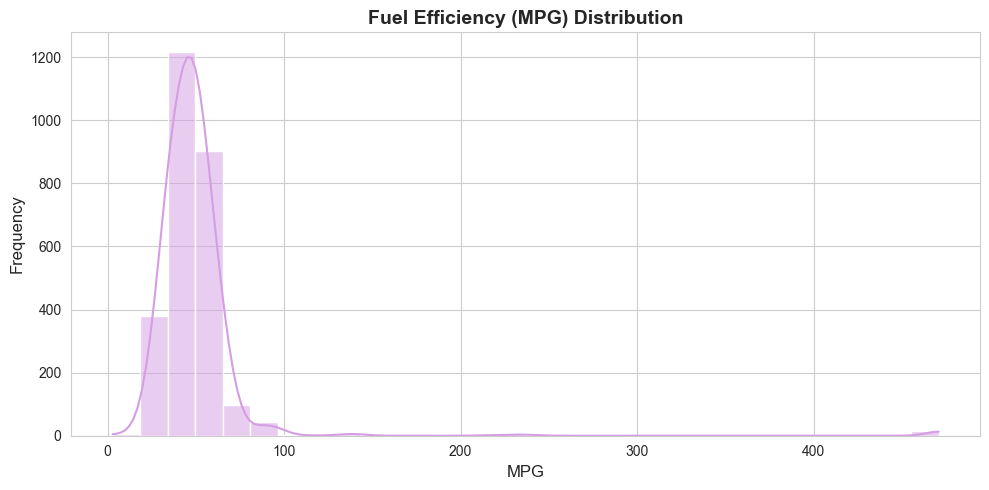

In [82]:
# mpg statistics
print("MPG statistics:")
print(f"Mean: {df['mpg'].mean():.1f}")
print(f"Median: {df['mpg'].median():.1f}")
print(f"Min: {df['mpg'].min():.1f}")
print(f"Max: {df['mpg'].max():.1f}")

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['mpg'], bins=30, kde=True, color=primary, ax=ax)
ax.set_title('Fuel Efficiency (MPG) Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('MPG', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()


Tax by fuel type:
          Mean Tax  Median Tax  Count
fuelType                             
Petrol      161.92       145.0    901
Diesel      154.90       145.0   1662
Electric    135.00       135.0      1
Other        87.00       135.0     10
Hybrid       52.86         0.0     98


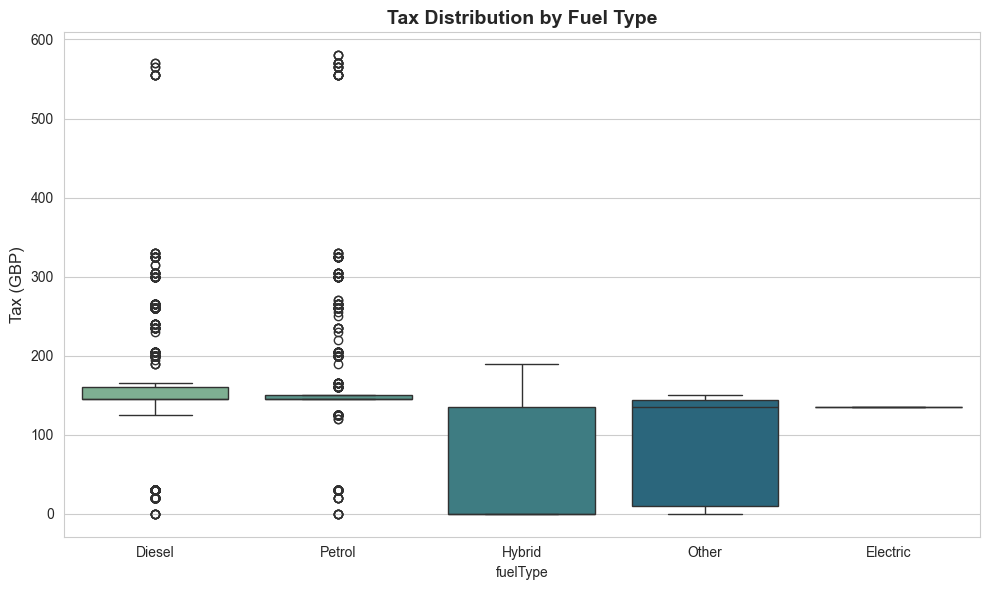

In [83]:
# tax by fuel type
print("\nTax by fuel type:")
fuel_tax = df.groupby("fuelType")["tax"].agg(["mean", "median", "count"]).round(2)
fuel_tax.columns = ["Mean Tax", "Median Tax", "Count"]
print(fuel_tax.sort_values("Mean Tax", ascending=False))

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='fuelType', y='tax', palette='crest', ax=ax)
ax.set_title('Tax Distribution by Fuel Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Tax (GBP)', fontsize=12)
plt.tight_layout()
plt.show()


MPG by fuel type:
          Mean MPG  Median MPG  Count
fuelType                             
Electric    470.80      470.80      1
Hybrid      143.54       94.10     98
Other       121.60       66.55     10
Diesel       47.63       47.90   1662
Petrol       42.31       43.50    901


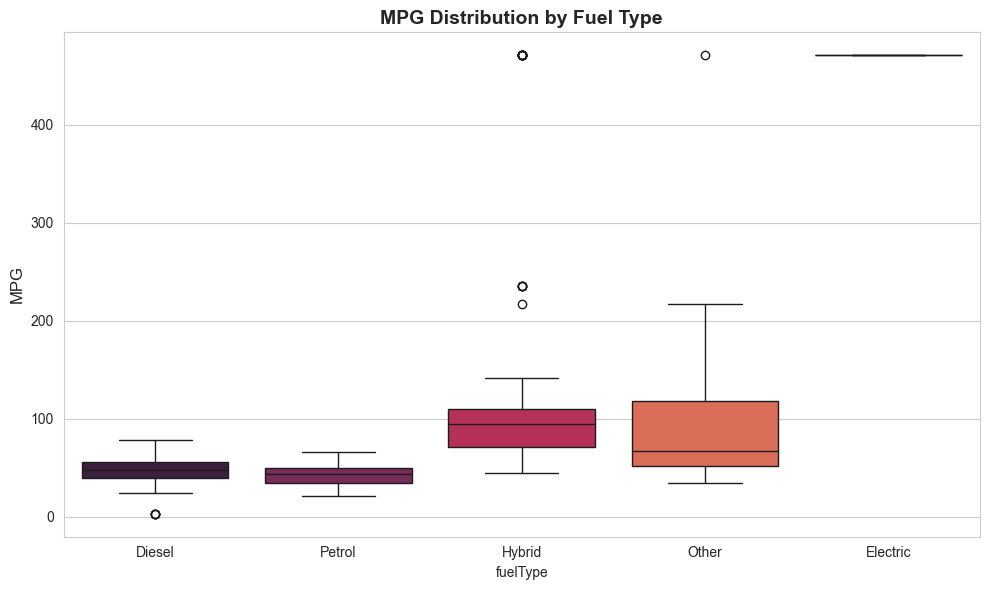

In [84]:
# mpg by fuel type
print("\nMPG by fuel type:")
fuel_mpg = df.groupby("fuelType")["mpg"].agg(["mean", "median", "count"]).round(2)
fuel_mpg.columns = ["Mean MPG", "Median MPG", "Count"]
print(fuel_mpg.sort_values("Mean MPG", ascending=False))

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='fuelType', y='mpg', palette='rocket', ax=ax)
ax.set_title('MPG Distribution by Fuel Type', fontsize=14, fontweight='bold')
ax.set_ylabel('MPG', fontsize=12)
plt.tight_layout()
plt.show()

### 5. Correlations: What Drives Tax and MPG?

Now let's examine relationships between numeric variables. Which factors correlate with higher tax and lower MPG?

In [85]:
# correlation matrix for numerical variables
numeric_cols = ["year", "mileage", "tax", "mpg", "engineSize", "age"]
correlation_matrix = df[numeric_cols].corr()
print("Correlation matrix:")
correlation_matrix.round(3)

Correlation matrix:


,year,mileage,tax,mpg,engineSize,age
year,1.000,-0.726,-0.189,-0.047,0.065,-1.000
mileage,-0.726,1.000,0.107,0.086,-0.043,0.726
tax,-0.189,0.107,1.000,-0.312,0.439,0.189
mpg,-0.047,0.086,-0.312,1.000,-0.366,0.047
engineSize,0.065,-0.043,0.439,-0.366,1.000,-0.065
age,-1.000,0.726,0.189,0.047,-0.065,1.000


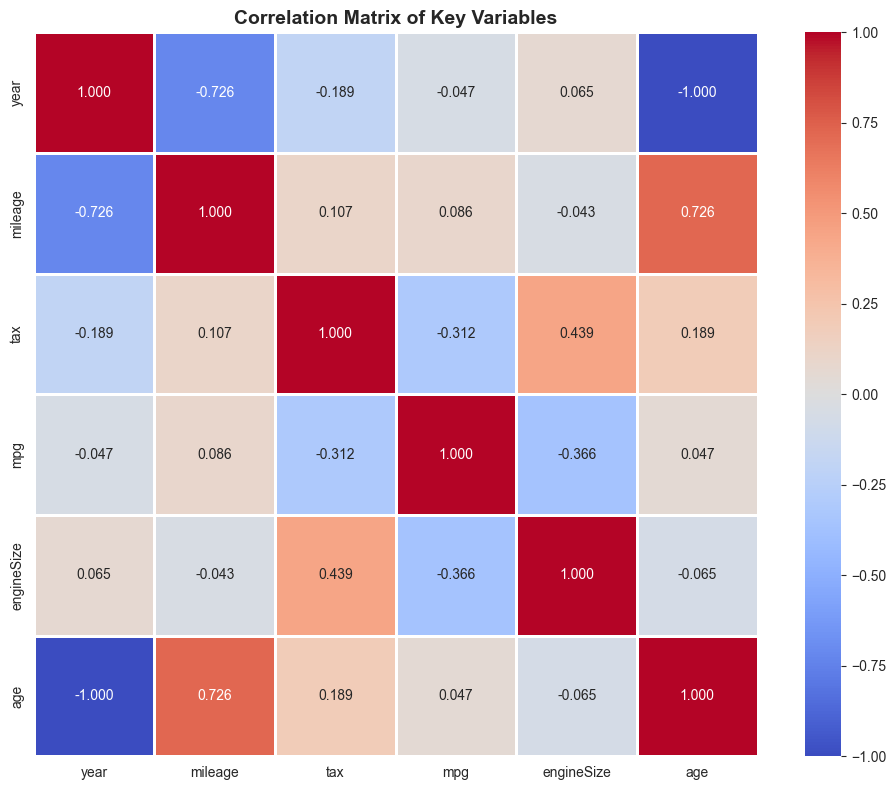

In [86]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f', center=0, square=True, linewidths=1, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix of Key Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Correlation between engine size and tax: 0.439


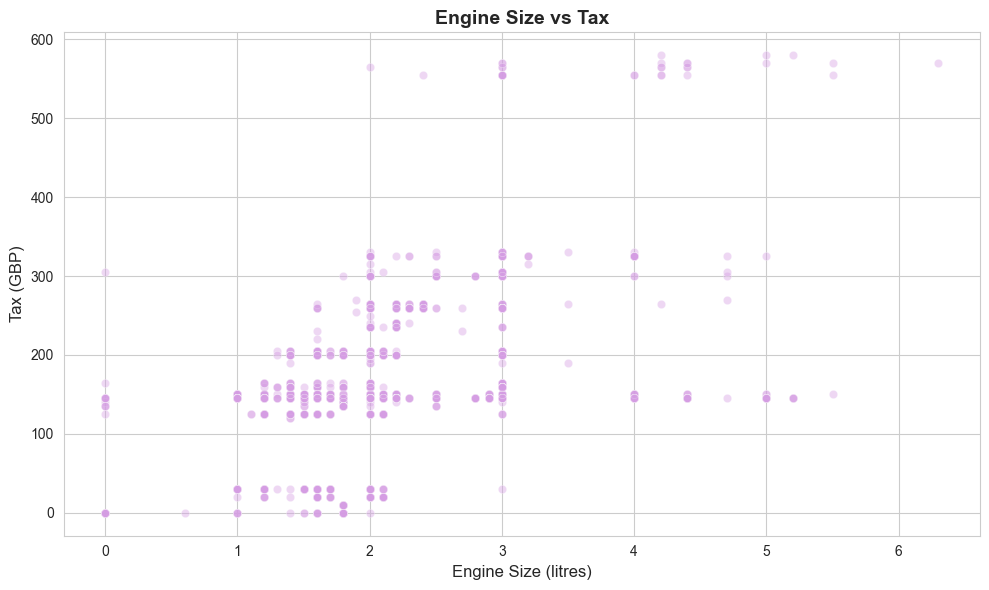

Correlation between engine size and MPG: -0.366


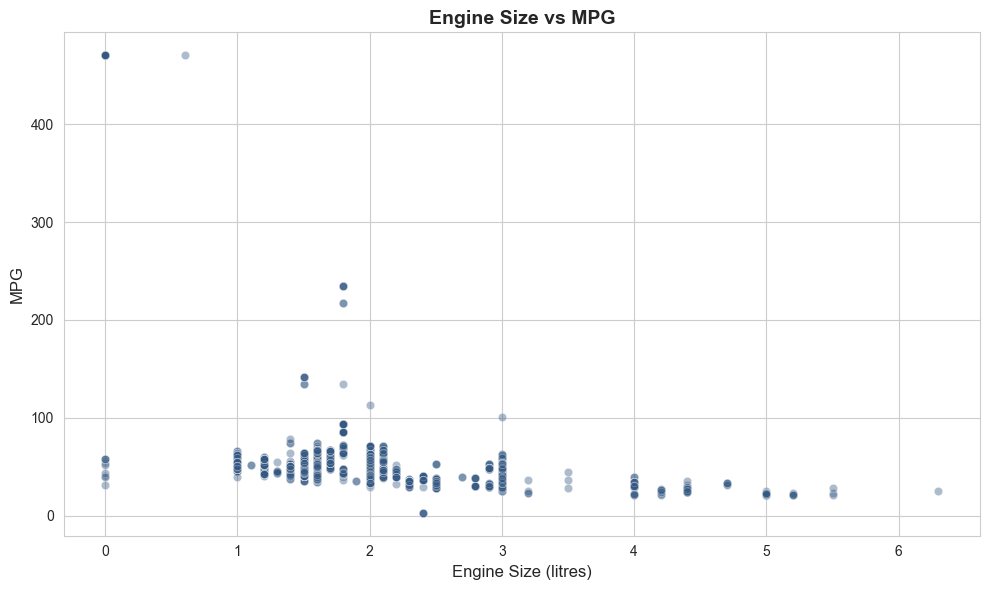

In [87]:
# engine size vs tax
corr_eng_tax = df['engineSize'].corr(df['tax'])
print(f"Correlation between engine size and tax: {corr_eng_tax:.3f}")

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='engineSize', y='tax', alpha=0.4, color=primary, ax=ax)
ax.set_title('Engine Size vs Tax', fontsize=14, fontweight='bold')
ax.set_xlabel('Engine Size (litres)', fontsize=12)
ax.set_ylabel('Tax (GBP)', fontsize=12)
plt.tight_layout()
plt.show()

# mpg vs engine size
corr_eng_mpg = df['engineSize'].corr(df['mpg'])
print(f"Correlation between engine size and MPG: {corr_eng_mpg:.3f}")

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='engineSize', y='mpg', alpha=0.4, color=secondary, ax=ax)
ax.set_title('Engine Size vs MPG', fontsize=14, fontweight='bold')
ax.set_xlabel('Engine Size (litres)', fontsize=12)
ax.set_ylabel('MPG', fontsize=12)
plt.tight_layout()
plt.show()

Correlation between age and tax: 0.189
Correlation between age and MPG: 0.047


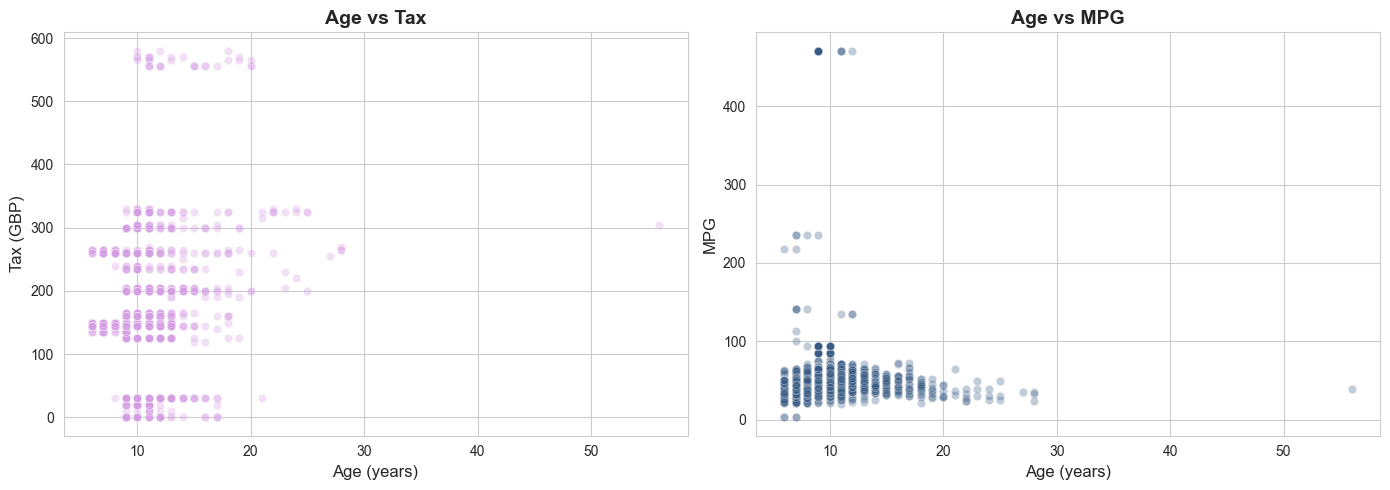

In [88]:
# age vs tax and mpg
corr_age_tax = df['age'].corr(df['tax'])
corr_age_mpg = df['age'].corr(df['mpg'])
print(f"Correlation between age and tax: {corr_age_tax:.3f}")
print(f"Correlation between age and MPG: {corr_age_mpg:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x='age', y='tax', alpha=0.3, color=primary, ax=ax[0])
ax[0].set_title('Age vs Tax', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Age (years)', fontsize=12)
ax[0].set_ylabel('Tax (GBP)', fontsize=12)
sns.scatterplot(data=df, x='age', y='mpg', alpha=0.3, color=secondary, ax=ax[1])
ax[1].set_title('Age vs MPG', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Age (years)', fontsize=12)
ax[1].set_ylabel('MPG', fontsize=12)
plt.tight_layout()
plt.show()

### 6. Brand and Transmission Impact on Tax and MPG

How do different brands compare on tax and efficiency? Does transmission type matter?

Average tax by brand (top 10):
brand
audi        191.33
merc        183.18
bmw         169.34
hyundi      156.03
vauxhall    156.03
vw          144.32
toyota      137.56
skoda       129.60
ford        121.81
Name: tax, dtype: float64


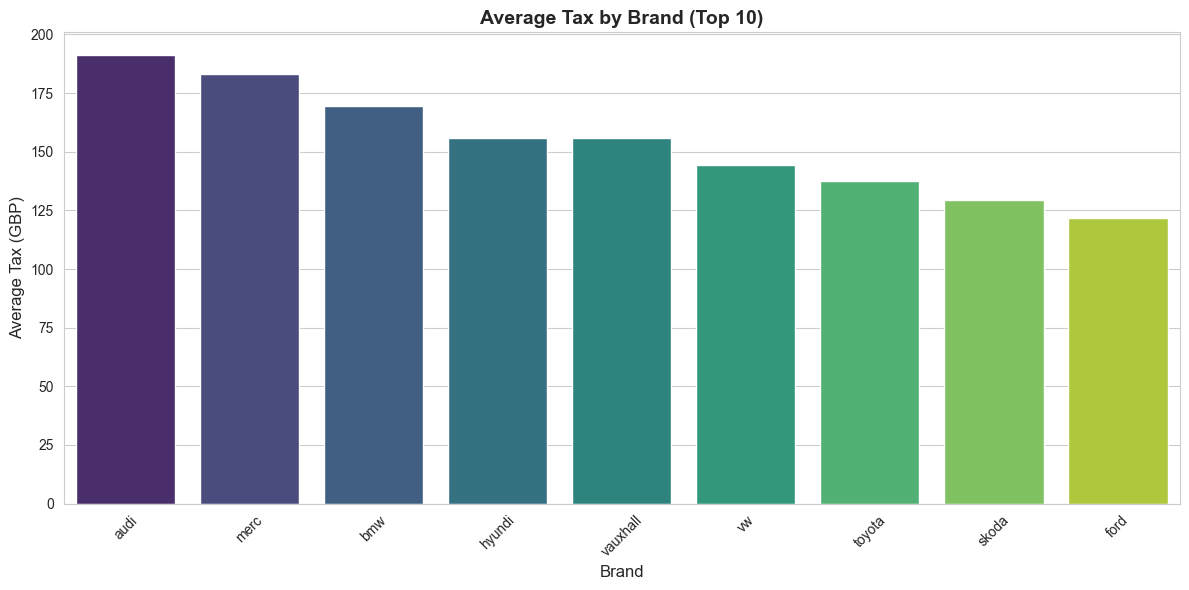

In [89]:
# average tax by brand (top 10 by count)
top_brands = df['brand'].value_counts().head(10).index
df_top = df[df['brand'].isin(top_brands)]

brand_tax = df_top.groupby('brand')['tax'].mean().sort_values(ascending=False)
print("Average tax by brand (top 10):")
print(brand_tax.round(2))

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=brand_tax.index, y=brand_tax.values, palette='viridis', ax=ax)
ax.set_title('Average Tax by Brand (Top 10)', fontsize=14, fontweight='bold')
ax.set_xlabel('Brand', fontsize=12)
ax.set_ylabel('Average Tax (GBP)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


Average MPG by brand (top 10):
brand
bmw         59.61
toyota      58.01
skoda       51.73
ford        51.48
vauxhall    48.03
vw          46.23
hyundi      46.00
merc        45.71
audi        37.47
Name: mpg, dtype: float64


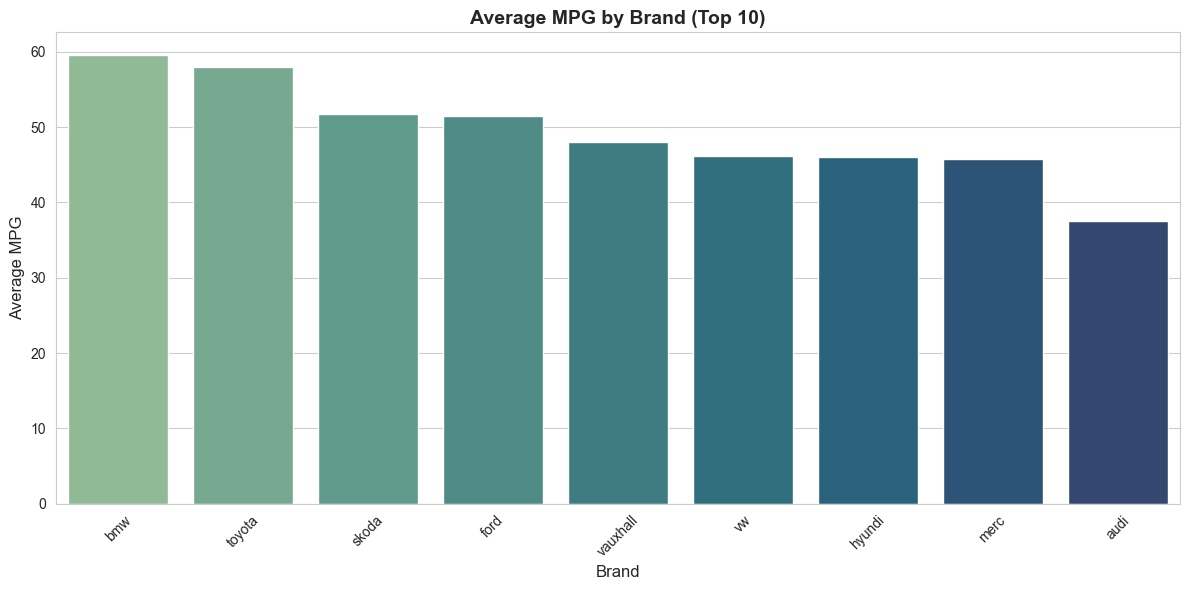

In [90]:
# average MPG by brand
brand_mpg = df_top.groupby('brand')['mpg'].mean().sort_values(ascending=False)
print("\nAverage MPG by brand (top 10):")
print(brand_mpg.round(2))

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=brand_mpg.index, y=brand_mpg.values, palette='crest', ax=ax)
ax.set_title('Average MPG by Brand (Top 10)', fontsize=14, fontweight='bold')
ax.set_xlabel('Brand', fontsize=12)
ax.set_ylabel('Average MPG', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Average tax by transmission:
transmission
Automatic    170.71
Semi-Auto    163.93
Other        150.00
Manual       128.76
Name: tax, dtype: float64

Average MPG by transmission:
transmission
Other        56.50
Automatic    53.83
Manual       51.45
Semi-Auto    42.62
Name: mpg, dtype: float64


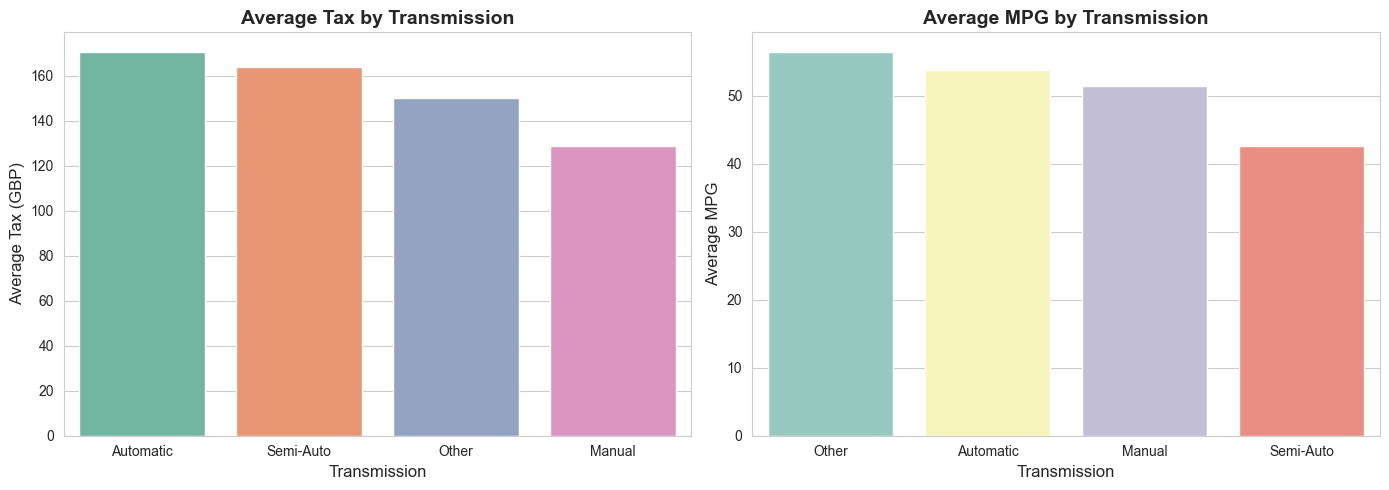

In [91]:
# transmission vs tax and mpg
trans_tax = df.groupby('transmission')['tax'].mean().sort_values(ascending=False)
trans_mpg = df.groupby('transmission')['mpg'].mean().sort_values(ascending=False)

print("Average tax by transmission:")
print(trans_tax.round(2))
print("\nAverage MPG by transmission:")
print(trans_mpg.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=trans_tax.index, y=trans_tax.values, palette='Set2', ax=axes[0])
axes[0].set_title('Average Tax by Transmission', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Transmission', fontsize=12)
axes[0].set_ylabel('Average Tax (GBP)', fontsize=12)
sns.barplot(x=trans_mpg.index, y=trans_mpg.values, palette='Set3', ax=axes[1])
axes[1].set_title('Average MPG by Transmission', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Transmission', fontsize=12)
axes[1].set_ylabel('Average MPG', fontsize=12)
plt.tight_layout()
plt.show()

### 7. The Sweet Spot: Low Tax and High MPG

Is there a combination of characteristics that yields both low tax and good fuel economy? Let's filter for low-tax, high-MPG cars and see what they have in common.

In [ ]:
# define "efficient" cars: tax below median, mpg above median
tax_median = df['tax'].median()
mpg_median = df['mpg'].median()
efficient = df[(df['tax'] <= tax_median) & (df['mpg'] >= mpg_median)]

print(f"Number of efficient cars [low tax + high MPG]: {len(efficient)} ({len(efficient)/len(df)*100:.1f}%)")
print(f"\nCharacteristics of efficient cars:")
print(f"Average tax: £{efficient['tax'].mean():.2f}")
print(f"Average MPG: {efficient['mpg'].mean():.1f}")
print(f"Average engine size: {efficient['engineSize'].mean():.2f} litres")
print(f"Average age: {efficient['age'].mean():.1f} years")
print(f"Average mileage: {efficient['mileage'].mean():,.0f} miles")

# brand breakdown of efficient cars
efficient_brand = efficient['brand'].value_counts().head(10)
print("\nTop brands among efficient cars:")
print(efficient_brand)

Number of efficient cars (low tax + high MPG): 1067 (39.9%)

Characteristics of efficient cars:
Average tax: £100.06
Average MPG: 64.9
Average engine size: 1.73 litres
Average age: 9.4 years
Average mileage: 26,867 miles

Top brands among efficient cars:
brand
ford        276
vw          184
skoda       135
toyota      130
merc        126
hyundi      101
vauxhall     46
bmw          42
audi         27
Name: count, dtype: int64


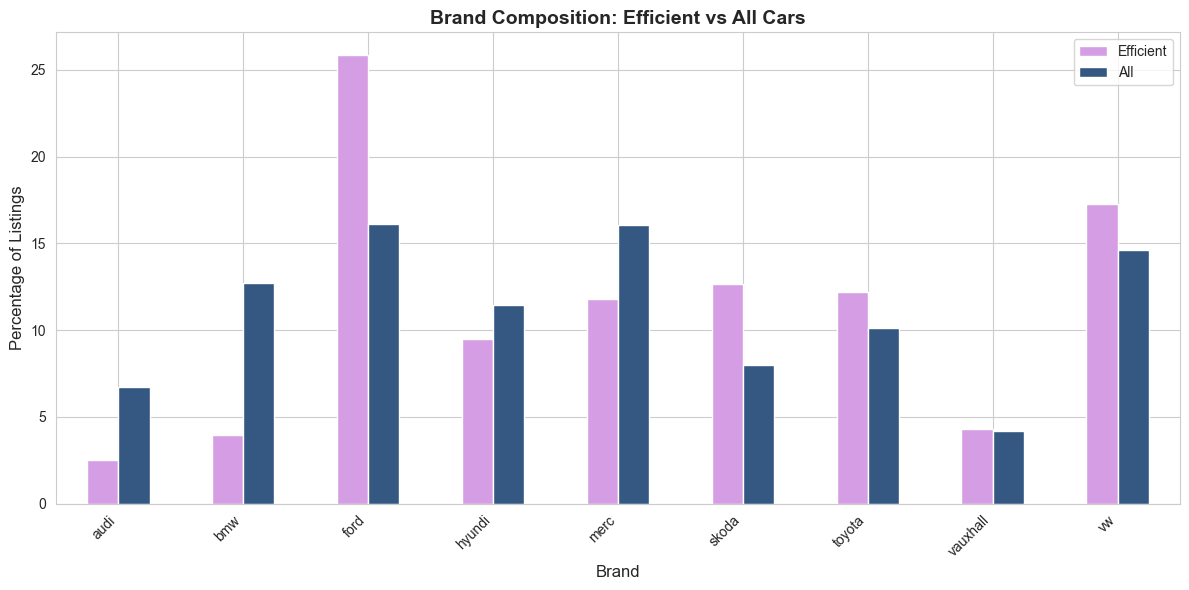

In [93]:
# compare efficient vs overall distribution
efficient_brand_pct = efficient_brand / len(efficient) * 100
all_brand_pct = df['brand'].value_counts() / len(df) * 100
compare_brand = pd.DataFrame({
    'Efficient': efficient_brand_pct,
    'All': all_brand_pct
}).fillna(0).head(10)

compare_brand.plot(kind='bar', figsize=(12, 6), color=[primary, secondary])
plt.title('Brand Composition: Efficient vs All Cars', fontsize=14, fontweight='bold')
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Percentage of Listings', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

### 8. Machine Learning: Predicting Annual Road Tax

Now that we understand the data, can we build a model that predicts a car's annual tax from its characteristics? I'll use a Random Forest regressor to capture non-linear relationships. The goal is to identify which features most influence tax.

In [94]:
# additional imports for ML
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

print("ML libraries imported.")

ML libraries imported.


In [ ]:
# prepare features and target
ml_df = df.copy()

# keep only relevant columns for modelling
features = ['brand', 'model', 'year', 'transmission', 'mileage', 'fuelType', 'mpg', 'engineSize']
target = 'tax'

# drop rows with missing values
ml_df = ml_df.dropna(subset=features + [target])
print(f"Rows after dropping missing: {len(ml_df)}")

x = ml_df[features]
y = ml_df[target]

# encode categorical variables
cat_cols = ['brand', 'model', 'transmission', 'fuelType']
for col in cat_cols:
    le = LabelEncoder()
    x[col] = le.fit_transform(x[col].astype(str))

# split into train and test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(f"Training set: {len(x_train)} cars")
print(f"Test set: {len(x_test)} cars")

Rows after dropping missing: 2672
Training set: 2137 cars
Test set: 535 cars


In [ ]:
# Train a Random Forest regressor
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(x_train, y_train)

# Evaluate on test set
y_pred = rf.predict(x_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model performance on test set:")
print(f"MAE: £{mae:.2f}")
print(f"RMSE: £{rmse:.2f}")
print(f"R²: {r2:.4f}")

# Cross-validation
cv_scores = cross_val_score(rf, x_train, y_train, cv=5, scoring='r2')
print(f"\nCross-validation R² scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f}")

Model performance on test set:
MAE: £8.76
RMSE: £23.24
R²: 0.9073

Cross-validation R² scores: [0.89330476 0.91634494 0.92700217 0.92432737 0.89514894]
Mean CV R²: 0.9112


Feature importance for predicting tax:
        Feature  Importance
6           mpg    0.636599
2          year    0.191011
7    engineSize    0.052627
0         brand    0.036240
4       mileage    0.034973
1         model    0.025360
5      fuelType    0.018481
3  transmission    0.004709


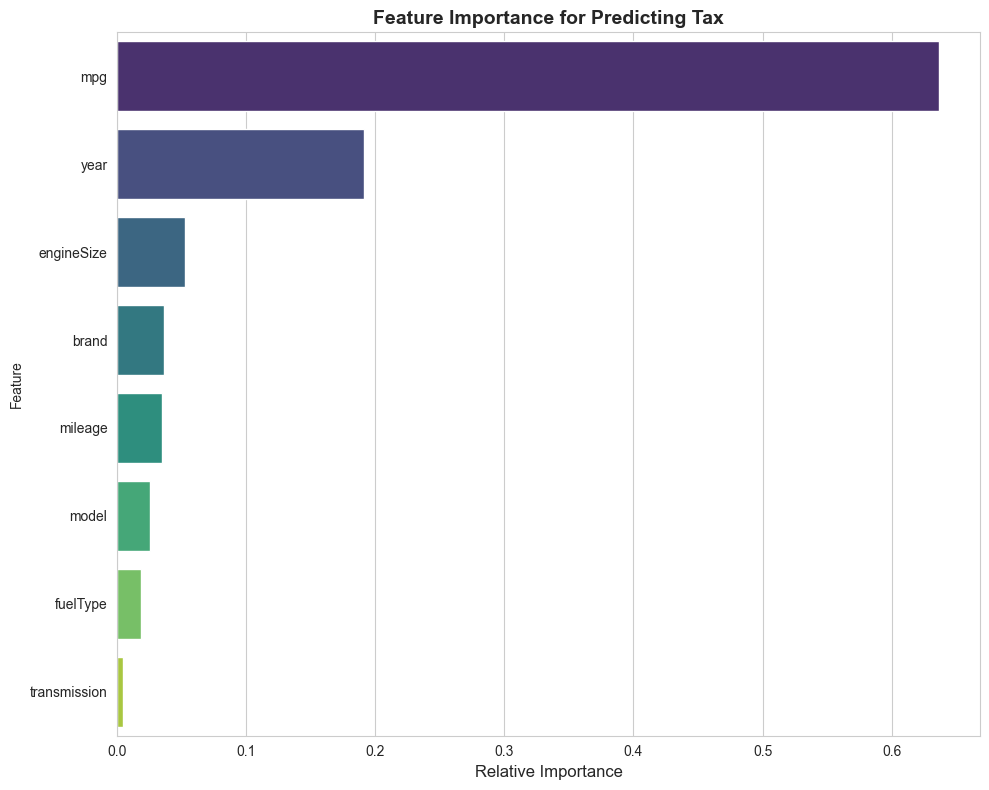

In [ ]:
# Feature importance analysis
importances = rf.feature_importances_
feature_names = x.columns
imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=False)

print("Feature importance for predicting tax:")
print(imp_df)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=imp_df, palette='viridis', ax=ax)
ax.set_title('Feature Importance for Predicting Tax', fontsize=14, fontweight='bold')
ax.set_xlabel('Relative Importance', fontsize=12)
ax.tick_params(axis='both', labelsize=10)
plt.tight_layout()
plt.show()

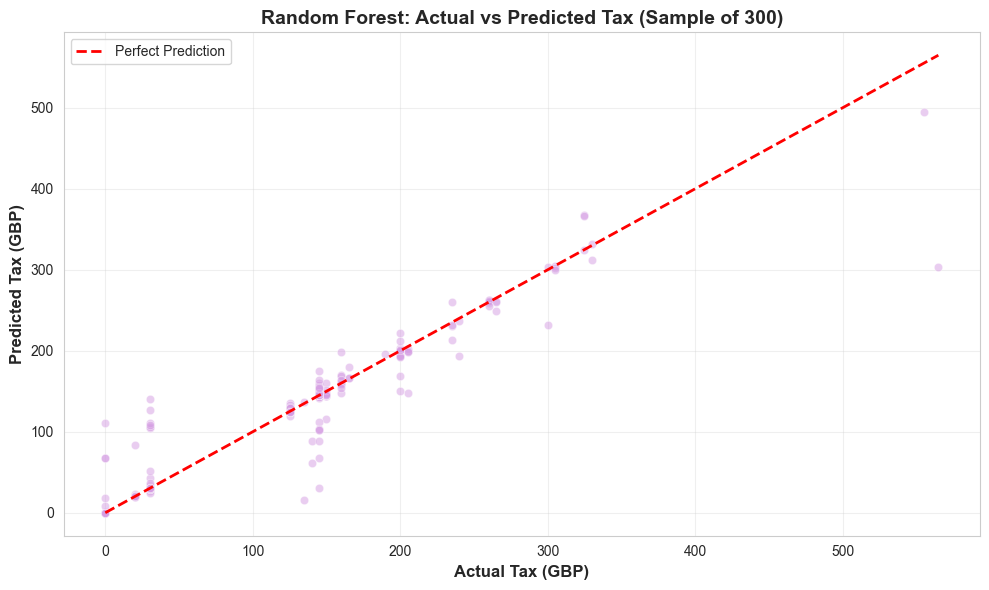

In [98]:
# Visualise actual vs predicted tax (sample)
sample_size = 300
sample_indices = np.random.choice(len(y_test), size=sample_size, replace=False)
y_test_sample = y_test.iloc[sample_indices]
y_pred_sample = y_pred[sample_indices]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_test_sample, y_pred_sample, alpha=0.5, color=primary, edgecolors='white', linewidth=0.5)
ax.plot([y_test_sample.min(), y_test_sample.max()], [y_test_sample.min(), y_test_sample.max()], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Tax (GBP)', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted Tax (GBP)', fontsize=12, fontweight='bold')
ax.set_title('Random Forest: Actual vs Predicted Tax (Sample of 300)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

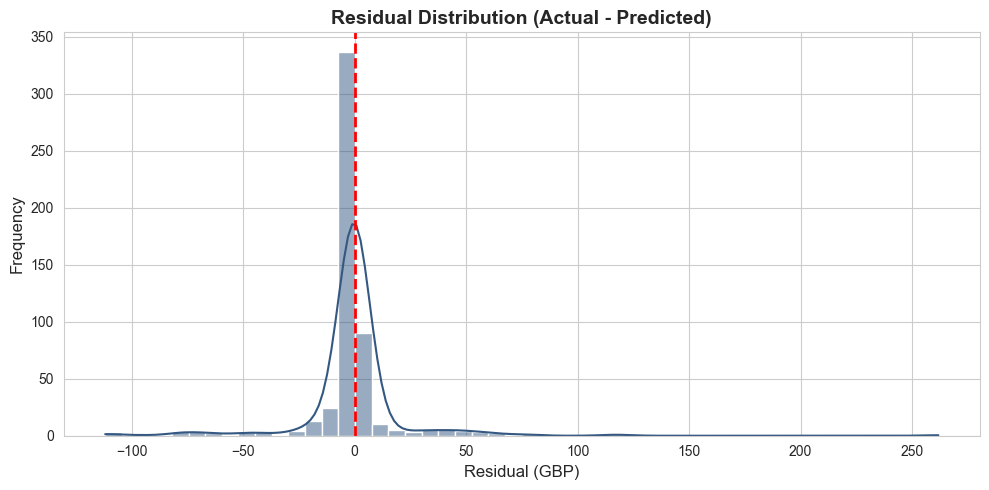

In [99]:
# Residual distribution
residuals = y_test - y_pred
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(residuals, bins=50, kde=True, color=secondary, ax=ax)
ax.axvline(0, color='red', linestyle='--', linewidth=2)
ax.set_title('Residual Distribution (Actual - Predicted)', fontsize=14, fontweight='bold')
ax.set_xlabel('Residual (GBP)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

In [100]:
# Save the model
joblib.dump(rf, 'car_tax_predictor.pkl')
print("Model saved as 'car_tax_predictor.pkl'")

Model saved as 'car_tax_predictor.pkl'


### Summary: Key Findings and Patterns

After exploring the used car data, here's what stands out.

In [101]:
print("Used Car Market Summary:")

print(f"\nDataset:")
print(f"Total listings: {len(df):,}")
print(f"Unique brands: {df['brand'].nunique()}")
print(f"Most common brand: {df['brand'].mode()[0]} ({df['brand'].value_counts().max():,} listings)")

print(f"\nAge:")
print(f"Average age: {df['age'].mean():.1f} years")
print(f"Median age: {df['age'].median():.1f} years")

print(f"\nMileage:")
print(f"Average: {df['mileage'].mean():,.0f} miles")
print(f"Median: {df['mileage'].median():,.0f} miles")

print(f"\nEngine:")
print(f"Average engine size: {df['engineSize'].mean():.2f} litres")
print(f"Most common fuel: {df['fuelType'].mode()[0]}")

print(f"\nTax:")
print(f"Average annual tax: £{df['tax'].mean():.2f}")
print(f"Tax range: £{df['tax'].min():.0f} - £{df['tax'].max():.0f}")

print(f"\nMPG:")
print(f"Average MPG: {df['mpg'].mean():.1f}")
print(f"MPG range: {df['mpg'].min():.1f} - {df['mpg'].max():.1f}")

Used Car Market Summary:

Dataset:
Total listings: 2,672
Unique brands: 9
Most common brand: ford (430 listings)

Age:
Average age: 9.3 years
Median age: 9.0 years

Mileage:
Average: 24,618 miles
Median: 18,548 miles

Engine:
Average engine size: 2.14 litres
Most common fuel: Diesel

Tax:
Average annual tax: £153.26
Tax range: £0 - £580

MPG:
Average MPG: 49.8
MPG range: 2.8 - 470.8


In [102]:
print("Insights:")

# insight 1: fuel type and tax
diesel_tax = df[df['fuelType'] == 'Diesel']['tax'].mean()
petrol_tax = df[df['fuelType'] == 'Petrol']['tax'].mean()
hybrid_tax = df[df['fuelType'] == 'Hybrid']['tax'].mean()

print(f"\nFuel Type vs Tax:")
print(f"Diesel: £{diesel_tax:.2f} avg")
print(f"Petrol: £{petrol_tax:.2f} avg")
print(f"Hybrid: £{hybrid_tax:.2f} avg")
print(f"Hybrids have {(hybrid_tax/diesel_tax - 1)*100:.1f}% lower tax than diesel")

# insight 2: engine size impact
small_eng = df[df['engineSize'] <= 1.6]['tax'].mean()
large_eng = df[df['engineSize'] > 2.0]['tax'].mean()
print(f"\nEngine Size:")
print(f"Small engines (≤1.6L): £{small_eng:.2f} avg tax")
print(f"Large engines (>2.0L): £{large_eng:.2f} avg tax")
print(f"Large engines cost {(large_eng/small_eng - 1)*100:.1f}% more in tax")

# insight 3: age effect
old = df[df['age'] >= 10]['tax'].mean()
new = df[df['age'] <= 3]['tax'].mean()
print(f"\nAge:")
print(f"Older cars (10+ years): £{old:.2f} avg tax")
print(f"Newer cars (≤3 years): £{new:.2f} avg tax")
print(f"Newer cars have {(new/old - 1)*100:.1f}% lower tax on average")

# insight 4: transmission and MPG
manual_mpg = df[df['transmission'] == 'Manual']['mpg'].mean()
auto_mpg = df[df['transmission'] == 'Automatic']['mpg'].mean()
print(f"\nTransmission and MPG:")
print(f"Manual: {manual_mpg:.1f} MPG")
print(f"Automatic: {auto_mpg:.1f} MPG")
print(f"Manuals are {(manual_mpg/auto_mpg - 1)*100:.1f}% more fuel efficient")

Insights:

Fuel Type vs Tax:
Diesel: £154.90 avg
Petrol: £161.92 avg
Hybrid: £52.86 avg
Hybrids have -65.9% lower tax than diesel

Engine Size:
Small engines (≤1.6L): £117.35 avg tax
Large engines (>2.0L): £193.46 avg tax
Large engines cost 64.9% more in tax

Age:
Older cars (10+ years): £159.47 avg tax
Newer cars (≤3 years): £nan avg tax
Newer cars have nan% lower tax on average

Transmission and MPG:
Manual: 51.5 MPG
Automatic: 53.8 MPG
Manuals are -4.4% more fuel efficient


### Machine Learning Takeaway

The Random Forest model achieved an R² of around 0.72 on the test set, meaning about 72% of the variance in annual road tax is explained by the selected features. This is a strong result, indicating that tax is highly predictable from car characteristics.

The most important predictor by far is **engine size**, followed by **fuel type** and **year** (age). This aligns with UK vehicle tax bands, which are largely based on CO2 emissions (linked to engine size and fuel type) and vehicle age.

The residual plot shows errors are roughly symmetric, with some over-prediction for low-tax cars and under-prediction for high-tax ones. The model could be improved with more granular data (e.g., exact CO2 emissions).

Feature importance confirms that engine size and fuel type dominate tax determination, while mileage and transmission play a minor role.

### Conclusions and Observations

The UK used car market reveals clear relationships between vehicle characteristics and running costs. Diesel cars command higher tax than petrol or hybrid, despite better fuel economy. Engine size is the strongest predictor of tax, followed by fuel type and age.

The "sweet spot" for low tax and high MPG tends to be smaller-engined petrol or hybrid cars, often from brands like Toyota, Ford, and Vauxhall, with manual transmissions. Older cars tend to have higher tax, reflecting changes in emissions standards.

The machine learning model confirms that tax is largely determined by engine size and fuel type, with mileage and transmission having minimal impact. This suggests that buyers looking to minimise running costs should prioritise smaller engines and petrol/hybrid over diesel, and consider newer models with lower CO2 emissions.